In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

pd.set_option('display.max_columns', 30)

In [3]:
columns = ['engine_id', 'cycle'] + \
          [f'op_setting_{i}' for i in range(1, 4)] + \
          [f's{i}' for i in range(1, 22)]

train = pd.read_csv('../data/raw/train_FD001.txt', 
                    sep=r'\s+', header=None, names=columns)
test = pd.read_csv('../data/raw/test_FD001.txt', 
                   sep=r'\s+', header=None, names=columns)
rul_test = pd.read_csv('../data/raw/RUL_FD001.txt', 
                       sep=r'\s+', header=None, names=['RUL'])

print(f"Train: {train.shape}, {train['engine_id'].nunique()} engines")
print(f"Test:  {test.shape}, {test['engine_id'].nunique()} engines")
train.head()

Train: (20631, 26), 100 engines
Test:  (13096, 26), 100 engines


,engine_id,cycle,op_setting_1,op_setting_2,op_setting_3,s1,s2,s3,s4,s5,s6,s7,s8,s9,s10,s11,s12,s13,s14,s15,s16,s17,s18,s19,s20,s21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,21.61,554.36,2388.06,9046.19,1.3,47.47,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,21.61,553.75,2388.04,9044.07,1.3,47.49,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,21.61,554.26,2388.08,9052.94,1.3,47.27,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,21.61,554.45,2388.11,9049.48,1.3,47.13,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,21.61,554.00,2388.06,9055.15,1.3,47.28,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


count    100.000000
mean     206.310000
std       46.342749
min      128.000000
25%      177.000000
50%      199.000000
75%      229.250000
max      362.000000
Name: cycle, dtype: float64


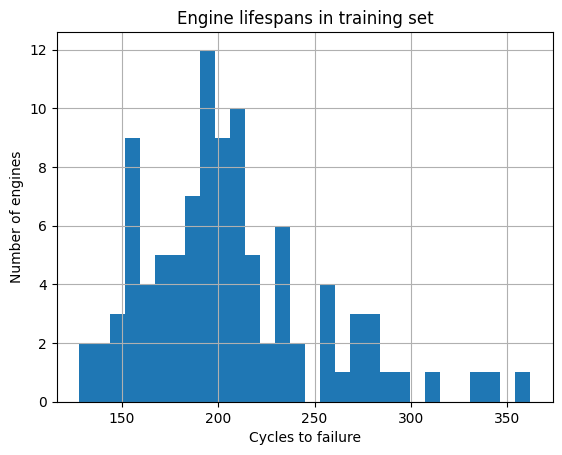

In [4]:
# How long does each engine run before failing in the training set?
engine_lifespans = train.groupby('engine_id')['cycle'].max()
print(engine_lifespans.describe())

engine_lifespans.hist(bins=30)
plt.xlabel('Cycles to failure')
plt.ylabel('Number of engines')
plt.title('Engine lifespans in training set');